In [2]:
import os
import zipfile
import cv2
import numpy as np


In [3]:
pip install torch torchvision scikit-learn matplotlib numpy pillow tqdm

In [4]:
import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # ECG images often grayscale
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [7]:
import os
import shutil
import random

# ================= CONFIG =================
SOURCE_DIR = "/content/drive/MyDrive/ECGG"     # your original dataset
DEST_DIR = "dataset"          # new dataset directory

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
random.seed(SEED)

# =========================================

classes = os.listdir(SOURCE_DIR)

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "test", cls, img)
        )

print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [8]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from collections import Counter

def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        counts[cls] = len(os.listdir(os.path.join(path, cls)))
    return counts

print("Train:", count_images("/content/dataset/train"))
print("Val:", count_images("/content/dataset/val"))
print("Test:", count_images("/content/dataset/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382, 'ECG Images of Patient that have History of MI (203)': 142}
Val: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81, 'ECG Images of Patient that have History of MI (203)': 30}
Test: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83, 'ECG Images of Patient that have History of MI (203)': 31}


handling class imbalance


In [10]:
class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = class_weights[train_dataset.targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
import os

def count_images_per_class(dataset_path):
    class_counts = {}
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                img for img in os.listdir(cls_path)
                if img.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return class_counts

print("Train set:", count_images_per_class("dataset/train"))
print("Validation set:", count_images_per_class("dataset/val"))
print("Test set:", count_images_per_class("dataset/test"))

Train set: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382, 'ECG Images of Patient that have History of MI (203)': 142}
Validation set: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81, 'ECG Images of Patient that have History of MI (203)': 30}
Test set: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83, 'ECG Images of Patient that have History of MI (203)': 31}


In [13]:
import numpy as np
from collections import Counter

targets = train_dataset.targets  # class labels
class_counts = Counter(targets)

print("Original class distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} images")

# Effective sampling per epoch
sampled_indices = list(train_loader.sampler)
sampled_targets = [targets[i] for i in sampled_indices]
sampled_counts = Counter(sampled_targets)

print("\nEffective distribution per epoch (after imbalance handling):")
for cls, count in sampled_counts.items():
    print(f"Class {cls}: {count} samples")

Original class distribution:
Class 0: 142 images
Class 1: 382 images
Class 2: 601 images

Effective distribution per epoch (after imbalance handling):
Class 0: 378 samples
Class 1: 402 samples
Class 2: 345 samples


In [14]:
class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attn = torch.softmax(torch.matmul(Q, K.transpose(-2, -1)) * self.scale, dim=-1)
        out = torch.matmul(attn, V)
        return out

In [15]:
class ResNetXAttn(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()

        self.attn = CrossAttention(dim=512)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)       # (B, 512)
        features = features.unsqueeze(1)  # (B, 1, 512)

        attn_out = self.attn(features)
        attn_out = attn_out.squeeze(1)

        return self.classifier(attn_out)

In [16]:
model = ResNetXAttn(NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


In [17]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0

    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [18]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return all_labels, all_preds

In [19]:
for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss:.4f}")

100%|██████████| 71/71 [00:56<00:00,  1.25it/s]


Epoch [1/20], Loss: 0.4333


100%|██████████| 71/71 [00:53<00:00,  1.33it/s]


Epoch [2/20], Loss: 0.2128


100%|██████████| 71/71 [00:52<00:00,  1.36it/s]


...

Epoch [18/20], Loss: 0.0596


100%|██████████| 71/71 [00:52<00:00,  1.34it/s]


Epoch [19/20], Loss: 0.0642


100%|██████████| 71/71 [00:52<00:00,  1.35it/s]

Epoch [20/20], Loss: 0.0854


In [20]:
labels, preds = evaluate(model, val_loader)
print("\nClassification Report:")
print(classification_report(labels, preds))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.83      0.90      0.86        81
           2       0.93      0.88      0.91       128

    accuracy                           0.90       239
   macro avg       0.92      0.93      0.92       239
weighted avg       0.91      0.90      0.90       239



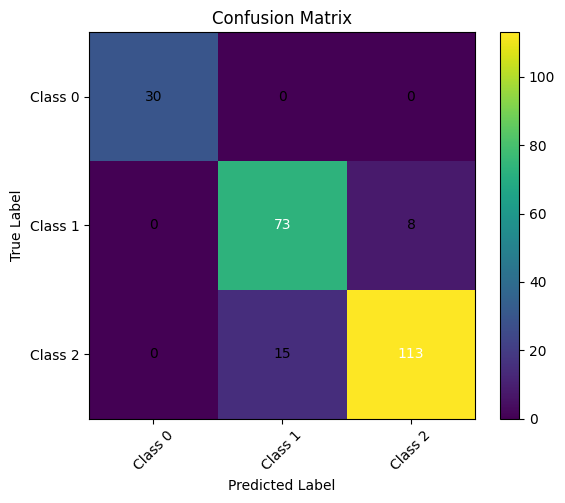

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(labels, preds)

# Class names (change if needed)
class_names = ["Class 0", "Class 1","Class 2"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add numbers inside cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

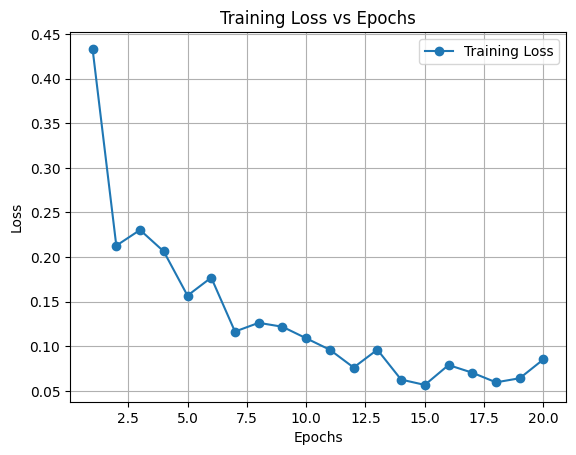

In [22]:
import matplotlib.pyplot as plt

# Your training loss values
train_loss = [
    0.4333, 0.2128, 0.2304, 0.2063, 0.1568,
    0.1770, 0.1165, 0.1263, 0.1219, 0.1090,
    0.0961, 0.0762, 0.0962, 0.0627, 0.0567,
    0.0790, 0.0704, 0.0596, 0.0642, 0.0854
]

epochs = range(1, 21)

# Plot
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Training Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend()
plt.grid()

plt.show()

In [25]:
import torch
from PIL import Image
import torchvision.transforms as transforms

# 🔹 Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔹 The model is already trained and available in the 'model' variable.
# model.load_state_dict(torch.load('best_model.pth', map_location=device)) # This line is removed
model.to(device)
model.eval()

# 🔹 Define class names (CHANGE according to your dataset)
class_names = ['Class 0', 'Class 1', 'Class 2'] # Updated to match notebook's class_names variable

# 🔹 Define same transforms used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # change if you used different size
    transforms.Grayscale(num_output_channels=3), # Added to match train/val transforms
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # Updated to match train/val transforms
])

# 🔹 Prediction function
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    predicted_class = class_names[predicted.item()]
    return predicted_class

# 🔹 Test with your image path
image_path = "/content/dataset/test/ECG Images of Patient that have abnormal heart beats (548)/HB   (11).jpg"   # <-- CHANGE THIS
result = predict_image(image_path)

print("Predicted Class:", result)

Predicted Class: Class 1


In [26]:
import torch

# 🔹 Step 1: Save model weights
save_path = 'resnet_attention_weights.pth'
torch.save(model.state_dict(), save_path)

print("✅ Model weights saved at:", save_path)


# 🔹 Step 2: Download to your local system (Colab)
from google.colab import files

files.download(save_path)

✅ Model weights saved at: resnet_attention_weights.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
torch.save(model.state_dict(), "resnet_attention_weights.pth")

In [29]:
torch.save(model.state_dict(), "resnet_attention_weights.pth")

In [33]:
import torch
from google.colab import files

# Ensure the model is saved right before downloading
torch.save(model.state_dict(), "resnet_attention_weights.pth")
print("Model weights ensured to be saved.")

files.download("resnet_attention_weights.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
torch.save(model.state_dict(), "resnet_attention_weights.pth")

In [35]:
import os
print(os.path.getsize("resnet_attention_weights.pth"))

48472451


In [36]:
import torch
from google.colab import files

# Ensure the model is saved right before downloading
torch.save(model.state_dict(), "resnet_attention_weights.pth")
print("Model weights ensured to be saved.")

files.download("resnet_attention_weights.pth")

Model weights ensured to be saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
print(train_dataset.classes)

['ECG Images of Patient that have History of MI (203)', 'ECG Images of Patient that have abnormal heart beats (548)', 'Normal Person ECG Images (859)']
